# Decision Trees

This lab explores decision tree classification, predicting which drug a patient should be prescribed based on health parameters.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data & EDA
Download the dataset and display basic info and missing values.

In [8]:
DATA_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/"
    "labs/Module%203/data/drug200.csv"
)
df = pd.read_csv(DATA_URL)
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB
None

Missing values:
 Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


In [9]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


## 2. Pre-processing
Encode categorical features (`Sex`, `BP`, `Cholesterol`) into numerical representations.

In [10]:
encoders = {}
for col in ["Sex", "BP", "Cholesterol"]:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY


## 3. Correlation Analysis
Map target variable to numeric and examine correlations to find the most significant features.

In [11]:
drug_map = {"drugA": 0, "drugB": 1, "drugC": 2, "drugX": 3, "drugY": 4}
df["Drug_num"] = df["Drug"].map(drug_map)
print(
    df.select_dtypes(include="number")
    .corr()["Drug_num"]
    .drop("Drug_num")
    .sort_values(ascending=False)
)

Na_to_K        0.589120
BP             0.372868
Cholesterol    0.055629
Age           -0.004828
Sex           -0.098573
Name: Drug_num, dtype: float64


## 4. Modeling
Split the data into features (X) and target (y), train a Decision Tree Classifier, and evaluate.

In [12]:
X = df.drop(columns=["Drug", "Drug_num"])
y = df["Drug"]

# Proper train/test split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=32, stratify=y
)

drug_tree = DecisionTreeClassifier(criterion="entropy", max_depth=4)
drug_tree.fit(X_train, y_train)

y_pred = drug_tree.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



## 5. Visualize Tree
Plot the tree to interpret the decision criteria.

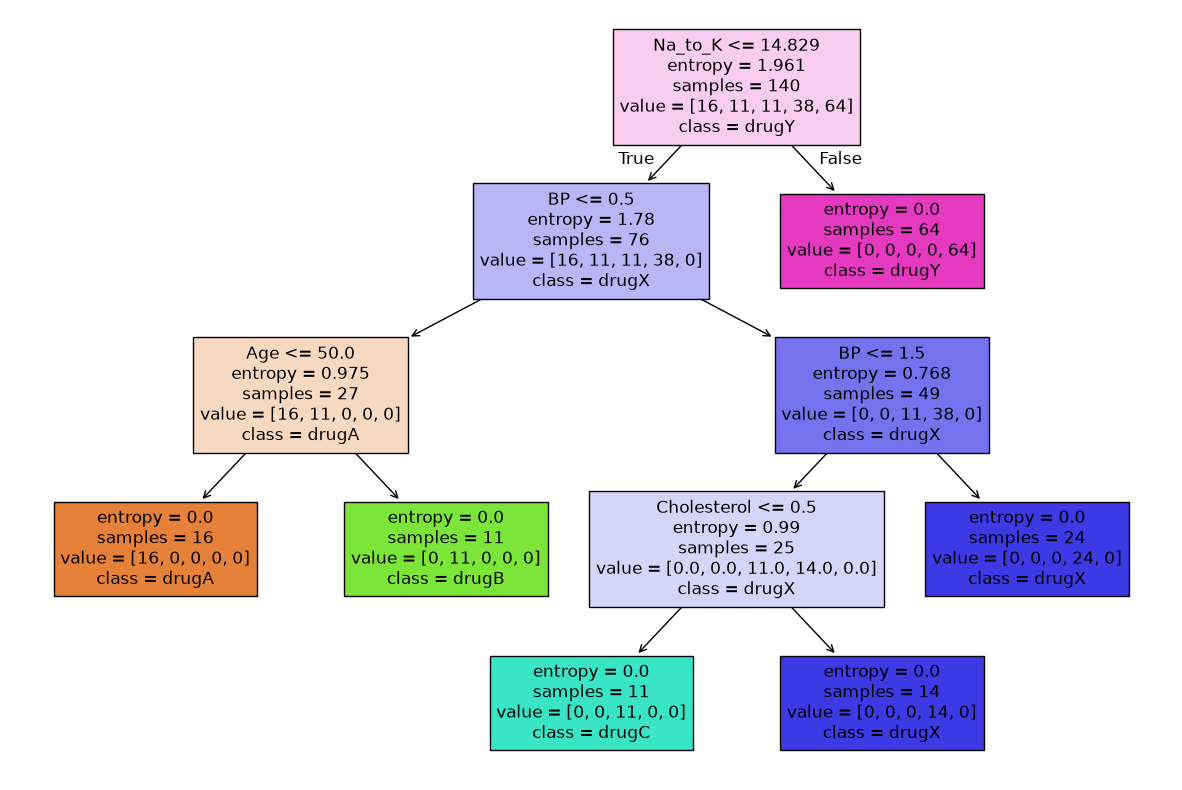

In [13]:
plt.figure(figsize=(15, 10))
plot_tree(drug_tree, feature_names=X.columns.tolist(), class_names=drug_tree.classes_.tolist(), filled=True)
plt.show()